# 2.2 - Amostras de Tamanho Variável

## População e Amostras

Na estatística, a *população* e a *amostra* de dados são conceitos fundamentais, mas que podem ser facilmente confundidos. Compreendê-los é crítico para realizar abordagens em que se faz necessária a distinção desses termos para a interpretação correta de dados.

A população consiste do conjunto de *todas* as observações referentes a um conjunto de dados. Ou seja, se uma tabela possui informações sobre $N$ observações, a totalidade desses registros compõe a população. Já a amostra é um subconjunto da população que é explorado para análise, como uma determinada fração de $N$. 

<span id="qual-devo-analisar"></span>
### Qual devo analisar?

"Os dados da população são usados quando sua pergunta de pesquisa exige isso, ou quando você tem acesso a dados de todos os membros da população. Geralmente, é fácil coletar dados de toda a população apenas quando ela é pequena, acessível e cooperativa.

Exemplo:

- Um gerente de marketing de uma pequena padaria local quer entender as preferências dos clientes. Eles coletam dados sobre a compra de pães de cada cliente durante um mês. Como a base de clientes é limitada e acessível, eles analisam toda a população para identificar tendências.

Quando usar uma Amostra:

- Quando sua população é grande, geograficamente espalhada ou difícil de contatar, é necessário usar uma amostra. Com a análise estatística, você pode usar dados da amostra para fazer *inferências* ou testar hipóteses sobre os dados da população." [1]

## Pondo em prática

Vamos utilizar um banco de dados sobre materiais suprecondutores [3], mais especificamente a variável aleatória temperatura crítica - `critical_temp` - de cada um deles, a qual é medida em Kelvin. Essa medida marca a transição de um material para a fase de supercondutividade, sendo que é abaixo dessa temperatura que o material passa a atuar como um supercondutor [4].

Bom, vamos dar uma breve olhada em nossos dados.

In [63]:
import pandas as pd

df = pd.read_csv("superconductivity.csv")
temp_criticas: pd.Series = df["critical_temp"]

temp_criticas.describe()


count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

21 mil observações é um número robusto para a nossa análise, e podemos também verificar que se tratam de dados quantitativos contínuos - `float` - bem como não há dados faltando. Além disso, podemos notar que 50% dos dados estão abaixo de 20 K, com um mínimo de quase 0 K, e a outra metade está acima dessa medida, com um máximo de 185 K. Ademais, é notável a média de temperatura crítica de cerca de 34 K e um desvio padrão aproximadamente semelhante.

### Buscando uma boa proporção da amostra

Vamos supor um cenário em que precisemos de estatísticas de um conjunto de dados, mas que seja necessário otimizar os processos computacionais. No caso de muitas observações, averiguar a população em sua totalidade é prescindível, pois bastará uma amostra representativa dela. Mas qual deve ser o tamanho da amostra? 

Se nos basearmos apenas em algumas dezenas de observações aleatórias, a probabilidade das estatísticas (média, mediana, desvio padrão médio, etc...) variarem drasticamente de amostra para amostra seriam altíssimas. Dessa forma, esses dados apresentariam alta variância ($\text{Var}(X)$), o que ocasionaria um alto desvio padrão ($\sigma$) entre as amostras. Esses termos são definidos *para a população* como

$$
\tag{1.1}
\text{Var}(X) = \frac{1}{N} \sum_{i=1}^{N} (X_i - \mu)^2
$$

$$
\tag{1.2}
\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N} (X_i - \mu)^2}
$$

Em que $\mu$ indica a média dos valores da população $X$ e $\sigma$ é a raíz quadrada positiva da variância. Por conta de relação matemática, a variância também pode ser escrita como $\sigma^2$, assim como pode ser notado que reduzir a variância implica em reduzir o desvio padrão.

É importante pontuar a diferença de notação e de cálculo dessas métricas *para amostras*! 

$$
\tag{1.3}
s^2 = \frac{1}{n - 1}\sum_{i=1}^{n} (X_i - \bar{X})^2
$$

$$
\tag{1.4}
s = \sqrt{\frac{1}{n - 1}\sum_{i=1}^{n} (X_i - \bar{X})^2}
$$

Com $\bar{X}$ representando a média amostral, $n$, o número de observações da amostra, e o termo $\dfrac{1}{n}$ sendo alterado para $\dfrac{1}{n -1}$ pela *correção de Bessel* [5].

### O quão representativa é a amostra?

Quando uma amostra é formada a partir de uma parcela da população de dados, ela carrega consigo o *erro de amostra*, o qual está associado a diferenças entre parâmetros populacionais e a estatística amostral. Isto é, dados amostrais nunca representarão perfeitamente a população em termos de medidas como a média ou o desvio padrão. 

Nesse contexto, surge o *erro padrão da média* $(\text{EPM})$, também conhecido como *desvio* padrão da média. Essa medida estima o quão representativa uma amostra é com base no desvio padrão e o tamanho da amostra. Conforme [6], quando os dados populacionais são acessíveis, o $\text{EPM}$ pode ser calculado como

$$
\tag{1.5}
\text{$\text{EPM}$} = \frac{\sigma}{\sqrt{n}}
$$

Já na ausência desses dados, o $\text{EPM}$ pode ser *estimado* por

$$
\tag{1.5}
\text{$\text{EPM}$} \approx \frac{s}{\sqrt{n}}
$$


 Destarte, quanto menor o tamanho da amostra $n$, maior será o $\text{EPM}$ (supondo que $\sigma$ e $s$ não variem significantemente). Isso se traduz em uma maior incerteza acerca da fidelidade da amostra em relação à população, o que não é ideal. A escala de $\text{EPM}$ es´ta relacionada à variável aleatória, então é razoável que haja um mesmo valor de $\text{EPM}$ que para determinado parâmetro seria ótimo, enquanto para outro, péssimo. Por exemplo, um erro de alguns centímetros é irrelevante para cálculos astronômicos, mas crítico para a arquitetura de peças eletrônicas. Assim, surge o *Erro Padrão Relativo* $\text{EPR}$, o qual expressa o erro padrão da média das amostras como uma porcentagem da média [7], sendo uma forma mais intuitiva de observar se uma amostra é uma má representante da população.

$$
\tag{1.6}
\text{EPR} = \frac{\text{EPM}}{\bar{X}} = \frac{s}{\bar{X} \sqrt{n}}
$$

Tendo adquirido essas noções, é fácil concluir que é muito arriscado elencar uma amostra tão pequena para representar a população. Entretanto, se designarmos uma amostra muito grande, o ganho de otimização não será tão expressivo como desejado. Assim, como buscar o equilíbrio entre esses termos?

Iremos definir uma porcentagem da população que será aleatoriamente selecionada para compor 50 amostras (com reposição). De cada uma delas, será calculada a média, e então será registrado o desvio padrão desse conjunto de médias correspondente a cada tamanho de amostra.  
Um conjunto de médias com alto desvio padrão signifca que a média dos conjuntos varia demais a depender das amostras selecionadas, o que torna as *inferências* baseadas nessa amostragem improváveis de serem boas representativas da população.

Portanto, devemos buscar diminuir essa variância da amostra enquanto otimizamos o sistema de forma satisfatória.

<span id="funcao-trabalho"></span>
### Definindo a função para todo o trabalho

Vamos criar uma função que fará todos os passos acima mencionados. Ela deve receber dados da população no formato `pd.Series`, um conjunto de porcetagens, um número para a quantidade de amostras a cada análise, o desvio padrão da média da população ou da amostra e opcionalmente a média da população (para calcular o erro padrão relativo) e uma semente aleatória para a reprodução de resultados.

In [198]:
import numpy as np
import statistics as st
import time
from collections.abc import Sequence 

def df_analise_amostragem_aleatoria(
    dados: pd.Series,
    amostragem_pctg: Sequence[int | float],
    qntd_amostras: int,
    desvio_padrao: float,
    media_pop: float = 0,
    semente_aleatoria: int = 0
) -> pd.DataFrame:
    
    # variáveis para toda a função
    np.random.seed(semente_aleatoria)
    n_observacoes: int = len(dados)

    # Dicionário que servirá de base para montar o DataFrame
    stdev_amostras: dict = {
        "Amostragem (% pop.)": amostragem_pctg,
        "Desvio P. das médias": [],
        "Erro P. da Média": [],
        "Erro P. Relativo": [],
        "Tempo de execução (ms)": []
    }

    # sem a media_pop, não é possível calcular o erro padrão relativo
    if not media_pop:
        del stdev_amostras["Erro P. Relativo"]

    # For loop para cada % da população
    for pctg in amostragem_pctg:
        medias: list = []
        tamanho_amostra: int = int(n_observacoes * pctg / 100)

        # For loop para as 50 amostras com a % correspondente
        for _ in range(qntd_amostras):
            inicio = time.time()
            amostra = dados.sample(
                n=tamanho_amostra,
                replace=True
                )

            medias.append(amostra.mean())

        # Salvando dados das amostras de cada % no dicionário
        stdev_amostras["Desvio P. das médias"].append(st.stdev(medias))
        
        # erro padrão da média
        epm: float = desvio_padrao / (tamanho_amostra ** (1/2))
        stdev_amostras["Erro P. da Média"].append(epm)

        # erro padrão relativo
        if media_pop:
            epr: float = epm * 100 / media_pop
            stdev_amostras["Erro P. Relativo"].append(epr)
        
        # duração do processamento das 50 amostras
        duracao_liquida = (time.time() - inicio) * 1e3
        stdev_amostras["Tempo de execução (ms)"].append(duracao_liquida)
        
    
    # Retorna DataFrame sobre Desvio Padrão dos conjuntos de médias
    return pd.DataFrame.from_dict(stdev_amostras)

Definida a função, vamos aplicá-la sobre nosso dados `temp_criticas`, com 50 amostras por análise e amostragens de 5%, 6%, ... até 90%. Como temos acesso aos dados da população, podemos informar o desvio padrão da população e a média populacional. Para fins de reprodução dos resultados, será definida a semente aleatória como 42.

In [199]:
NUMERO_AMOSTRAS: int = 50
amostragem = range(5, 91) # [5, 6, 7, ..., 90]
dp_pop = st.pstdev(temp_criticas)
mean_pop = temp_criticas.mean()

dfa3 = df_analise_amostragem_aleatoria(
    dados = temp_criticas,
    amostragem_pctg = amostragem,
    qntd_amostras = NUMERO_AMOSTRAS,
    desvio_padrao= dp_pop,
    media_pop = mean_pop,
    semente_aleatoria = 42
    )

Vamos visualizar os resultados obtidos para as amostragens com parcelas de 10 em 10 porcento da população:

In [200]:
# Filtrando apenas valores desejados
filtro1 = dfa3["Amostragem (% pop.)"].isin(range(10, 91, 10))
df_filtrado = dfa3.loc[filtro1]

df_filtrado.style.format("{:.2f}").hide(axis='index')

Amostragem (% pop.),Desvio P. das médias,Erro P. da Média,Erro P. Relativo,Tempo de execução (ms)
10.00,0.89,0.74,2.16,0.43
20.00,0.42,0.53,1.53,0.86
30.00,0.43,0.43,1.25,0.63
40.00,0.40,0.37,1.08,1.36
50.00,0.36,0.33,0.97,0.72
60.00,0.25,0.30,0.88,0.79
70.00,0.27,0.28,0.82,1.54
80.00,0.25,0.26,0.76,0.91
90.00,0.22,0.25,0.72,0.97


Essa tabela corrobora com o que vem sido discutido: amostragens menores tendem a produzir dados menos representativos da população, como pode ser observado pela correlação negativa entre o tamanho da amostragem e as três estatísticas seguintes. Ademais, é notável como o desvio padrão da média das 50 amostras geradas tende a se aproximar do valor do erro padrão da média,

Ademais, como a população de dados é robusta, mesmo uma amostra com 10% do volume de dados da população é capaz de apresentar um erro padrão relativo de apenas 2.16%. Logicamente, o limiar de tolerância varia entre cada política e cada variável. De forma arbitrária, seja $1\%$ o limite tolerável para o erro padrão relativo. Busquemos a menor amostra que satisfaça essa condição:

In [201]:
filtro2 = dfa3["Erro P. Relativo"] <= 1
df_menores_erp = dfa3[filtro2]
menor_amostragem_satisfatoria = df_menores_erp.iloc[[0]]

# Estilo
menor_amostragem_satisfatoria.style.format("{:.2f}").hide(axis='index')

Amostragem (% pop.),Desvio P. das médias,Erro P. da Média,Erro P. Relativo,Tempo de execução (ms)
47.00,0.31,0.34,1.00,0.71


Ou seja, bastaria um pouco menos da metade da população para obter uma amostra satisfatória para 

In [202]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

GRAU_POLINOMIO = 2

x = dfa3[["Amostragem (% pop.)"]]
y = dfa3["Desvio P. das médias"]

pipeline = make_pipeline(
    PolynomialFeatures(GRAU_POLINOMIO, include_bias=False),
    LinearRegression(),
)

pipeline.fit(x, y)

dpm_previsto = pipeline.predict(x);

In [203]:
y = dfa3["Tempo de execução (ms)"]

modelo = LinearRegression()

modelo.fit(x, y)

tempo_previsto = modelo.predict(x)

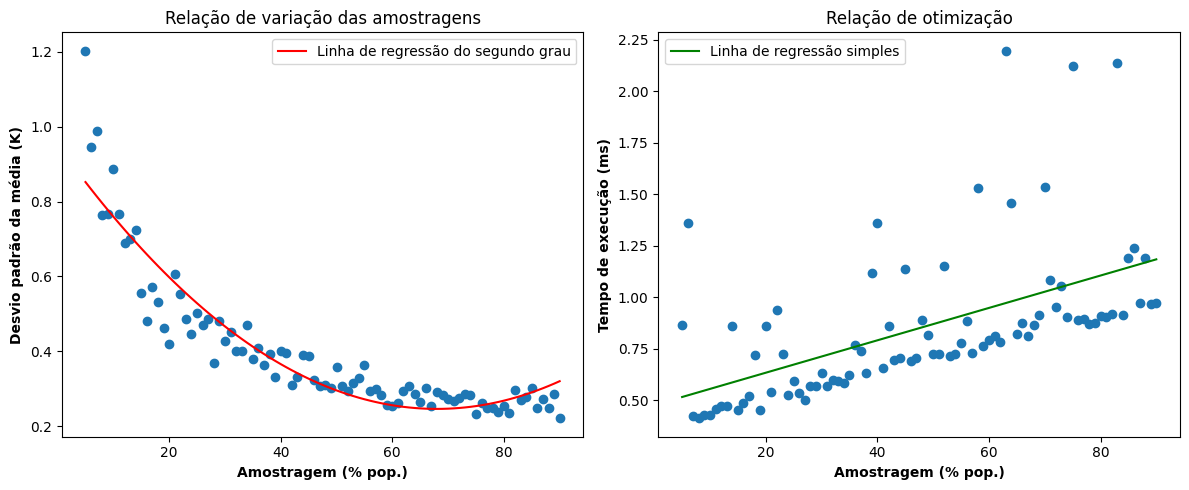

In [217]:
import matplotlib.pyplot as plt

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

# Plotagem de dados do desvio padrão
eixos[0].set_xlabel("Amostragem (% pop.)", fontweight="bold")
eixos[0].set_ylabel("Desvio padrão da média (K)", fontweight="bold")
eixos[0].set_title("Relação de variação das amostragens");

eixos[0].scatter(
    x=dfa3["Amostragem (% pop.)"],
    y=dfa3["Desvio P. das médias"]
    )

eixos[1].set_xlabel("Amostragem (% pop.)", fontweight="bold")
eixos[1].set_ylabel("Tempo de execução (ms)", fontweight="bold")
eixos[1].set_title("Relação de otimização")

eixos[1].scatter(
    x=dfa3["Amostragem (% pop.)"],
    y=dfa3["Tempo de execução (ms)"]
)

# Plotando linhas de regressão
eixos[0].plot(x.values.ravel(), dpm_previsto, color="red", label="Linha de regressão do segundo grau")
eixos[1].plot(x.values.ravel(), tempo_previsto, color="green", label="Linha de regressão simples")


eixos[0].legend()
eixos[1].legend()
# 4. Ajusta o espaçamento para evitar sobreposição de títulos/rótulos
plt.tight_layout()
plt.show();

[clique teste](#funcao-trabalho)

<span id="conclusao"></span>
## Conclusão

The standard error specifically for the sample mean. Measures how far the sample mean is likely to be from the true population mean.

## Referências

[1] https://www.geeksforgeeks.org/maths/population-and-sample-statistics/

[2] https://statisticsbyjim.com/hypothesis-testing/standard-error-mean/

[3] https://archive.ics.uci.edu/dataset/464/superconductivty+data

[4] Bardeen, J., Cooper, L. N., & Schrieffer, J. R. (1957). Theory of Superconductivity. Physical Review, 108(5), 1175–1204 https://journals.aps.org/pr/pdf/10.1103/PhysRev.108.1175

[5] https://www.statisticshowto.com/bessels-correction/

[6] https://www.scribbr.com/statistics/standard-error/

[7] https://www.geeksforgeeks.org/maths/relative-standard-error/#what-is-a-relative-standard-error-rse